# PROYECTO CHURN CON MACHINE LEARNING

#Modelo de aprendizaje automatico predictivo para la detección de riesgo de abandono escolar Secundaria en distritos del Perú utilizando datos oficiales del MINEDU

En este Notebook se desarrollara un proyecto con Machine Learning utilizando un Dataset de la plataforma porta de Datos Abiertos - Peru.

El objetivo principal es construir un modelo que pueda predecir los distritos que esten en riesgo de "fuga" los estudiantes a nivel Secundaria utilizando los datos oficiales de la MINEDU.
Se analizara la variable objetivo **TASA** debido a que gracias a esta variable podemos aproximar y lograr un calculo mas aproximado con los miles de registros que tiene el Dataset.


En el recorrido del notebook se observara las principales etapas del proyecto de Machine Learning:


- IMPORTACION DE LIBRERIAS

- CARGA DEL DATASET DESDE EL DRIVE

- EXPLORACION GENERAL DEL DATASET

- REVISION DE VALORES FALTANTES

- INGENIERIA DE DATOS

- SE ANALIZA LA VARIABLE OBJETIVO EN EL DATASET  

- GENERACION DE LA VARIABLE OBJETIVO ---> BINARIA

- LA TASA DE DESERCION POR DEPARTAMENTO

- SE PROCEDE A PREPARAR LOS DATOS PARA EL MODELO

- VISUALIZON DE LOS CLUSTERES

- MODELO REGRESION LOGISTICA Y K-MEANS APLICADO

- EXPERIMENTACION CON E2 Y E3

- COMPARACION DE EXPERIMENTOS (E2 vs. E3)

- VALIDACION CRUZADA

- CONCLUSIONES FINALES

- ANEXOS Y REFERENCIAS

# CONTEXTO DEL PROBLEMA
La perdida de estudiantes de un sistema escolar es un tema muy importante de ver debido a que no todos los numeros son iguales para todo el territorio Peruano , mientras otros paises muestran resultados mas positivos , tenemos al Peru en resultados muy deprimentes en el tema educativo , por eso se debe concentrar e identificar los distritos que  tienen una mayor tasa de fuga para poder tomar acciones de prevencion y retencion.
La variable que prediciremos es **TASA** es numerica (se calculara la tasa de desercion escolar)

1 : riesgo alto de desercion

0 : riesgo bajo de desercion

De esta forma el problema se procede a clasificar en tipo Categoria Binaria.

# IMPORTACION DE LIBRERIAS

1.-Primero se conecta el drive personal con GOOGLE COLAB

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2.-Aqui se procede a importar y ejecutar las librerias que se utilizaran para el proyecto como por ejemplo pandas y numpy para trabajar los datos , matplotlib y seaborn para poder realizar visualizaciones

In [2]:
# Importamos librerías para análisis de datos
import pandas as pd
import numpy as np

# Importamos librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos herramientas de scikit-learn para preparación, modelado y evaluación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configuramos algunas opciones de visualización
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42 #sirve para fijar la aleatoriedad y hacer que tus resultados sean reproducibles.
np.random.seed(RANDOM_STATE)

# CARGA DEL DATASET DESDE EL DRIVE

1.-Primero lo que se debe hacer es cargar los datos que se utilizara para el proyecto en este caso , yo Nicolas Torres he utilizado el Dataset de plataforma porta de Datos Abiertos - Peru. aqui adjunto el link para la descarga del archivo .CSV

FUENTE DATOS REALES : https://www.datosabiertos.gob.pe/dataset/tasa-y-n%C3%BAmero-de-desertores-en-educaci%C3%B3n-primaria-y-secundaria-20232024 . Luego de la descarga de los 2 archivos .CSV se debe establecer las rutas donde se tiene guardado el archivo en el Drive.

*NOTA:* Dentro del Archivo existen 2 hojas dentro del drive se tiene que adjuntar los dos en 1 sola carpeta para que pueda correr el codigo.

In [3]:
# Lee los archivos CSV sin especificar parse_dates para inspeccionar las columnas.
# Si tus archivos usan otro separador (ej. ';'), cámbialo aquí: sep=';'
primer_archivo = pd.read_csv("/content/drive/MyDrive/PROYECTO-IA/Tasa y número de desertores en Educación Primaria 2023-2024.csv", sep=',')
segundo_archivo = pd.read_csv("/content/drive/MyDrive/PROYECTO-IA/Tasa y número de desertores en Educación Secundaria 2023-2024.csv", sep=',')

print("Columnas del primer archivo:", primer_archivo.columns.tolist())
print("Columnas del segundo archivo:", segundo_archivo.columns.tolist())

#Aqui se procede a unir ambos archivos de formato .CSV
union_archivo = pd.concat([primer_archivo, segundo_archivo], ignore_index=True)
print(union_archivo.head())

# Para ver cuántas filas totales tiene el dataset combinado
print("Total de filas:", len(union_archivo))


Columnas del primer archivo: ['ubigeo', 'Departamento', 'Provincia', 'Distrito', 'desertor', 'denominador', 'Tasa']
Columnas del segundo archivo: ['ubigeo', 'Departamento', 'Provincia', 'Distrito', 'desertor', 'denominador', 'Tasa']
   ubigeo Departamento    Provincia     Distrito  desertor  denominador  \
0   10101     AMAZONAS  CHACHAPOYAS  CHACHAPOYAS        17         4146   
1   10102     AMAZONAS  CHACHAPOYAS     ASUNCION         0           12   
2   10103     AMAZONAS  CHACHAPOYAS       BALSAS         0          168   
3   10104     AMAZONAS  CHACHAPOYAS        CHETO         0           44   
4   10105     AMAZONAS  CHACHAPOYAS    CHILIQUIN         3           62   

       Tasa  
0  0.410034  
1  0.000000  
2  0.000000  
3  0.000000  
4  4.838710  
Total de filas: 3736


2.-Se observa las primeras filas del dataset unido y se puede identificar las variables ubigeo , Departamento , Provincia , Distrito , desertor , denominador, Tasa ----> nuestra variable objetivo.

In [4]:
# Ver las primeras filas
print("Primeras filas del dataset:")
print(union_archivo.head()) # Ver toda la tabla en formato DataFrame
print(union_archivo.shape)
union_archivo.head(10)   # muestra las primeras 10 filas en tabla


Primeras filas del dataset:
   ubigeo Departamento    Provincia     Distrito  desertor  denominador  \
0   10101     AMAZONAS  CHACHAPOYAS  CHACHAPOYAS        17         4146   
1   10102     AMAZONAS  CHACHAPOYAS     ASUNCION         0           12   
2   10103     AMAZONAS  CHACHAPOYAS       BALSAS         0          168   
3   10104     AMAZONAS  CHACHAPOYAS        CHETO         0           44   
4   10105     AMAZONAS  CHACHAPOYAS    CHILIQUIN         3           62   

       Tasa  
0  0.410034  
1  0.000000  
2  0.000000  
3  0.000000  
4  4.838710  
(3736, 7)


,ubigeo,Departamento,Provincia,Distrito,desertor,denominador,Tasa
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,17,4146,0.410034
1,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,0,12,0.000000
2,10103,AMAZONAS,CHACHAPOYAS,BALSAS,0,168,0.000000
3,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,44,0.000000
4,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,3,62,4.838710
5,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,4,259,1.544402
6,10107,AMAZONAS,CHACHAPOYAS,GRANADA,0,37,0.000000
7,10108,AMAZONAS,CHACHAPOYAS,HUANCAS,0,22,0.000000
8,10109,AMAZONAS,CHACHAPOYAS,LA JALCA,2,750,0.266667
9,10110,AMAZONAS,CHACHAPOYAS,LEIMEBAMBA,6,379,1.583113


# Primera observación del dataset

Al visualizar las primeras filas del dataset, vemos que cada registro representa distrito , la zona (ubigeo) y la cantidad de desertores que tiene el mismo , las columnas se observa el distrito , la provincia , denominador los estudiantes matriculados , la cantidad de desertores y La tasa proporcion de desercion calculado.

En la columna tasa es la que se utilizara para poder transformar los numeros a variables categoricas para poder saber el riesgo si es ALTO , BAJO , MEDIO.

Pero primero antes de tomar una decision de lo que se puede implementar primero debemos ver la estructura general del DATASET.

# Exploración general del dataset
Primero que todo debemos observar y conocer mejor la estructura del dataset que en este caso se visualizara:
- Las cantidades de filas y columnas que contiene
- Que tipo de Variable tiene
- Si el dataset posee datos faltantes o si seria necesario limpiar
- La estadistica resumida del dataset

In [5]:
print("=== PRIMARIA ===")
primer_archivo.info()
print("\n=== SECUNDARIA ===")
segundo_archivo.info()
display(union_archivo.describe())

=== PRIMARIA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890 entries, 0 to 1889
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ubigeo        1890 non-null   int64  
 1   Departamento  1890 non-null   object 
 2   Provincia     1890 non-null   object 
 3   Distrito      1890 non-null   object 
 4   desertor      1890 non-null   int64  
 5   denominador   1890 non-null   int64  
 6   Tasa          1890 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 103.5+ KB

=== SECUNDARIA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ubigeo        1846 non-null   int64  
 1   Departamento  1846 non-null   object 
 2   Provincia     1846 non-null   object 
 3   Distrito      1846 non-null   object 
 4   desertor      1846 non-null   int64  

,ubigeo,desertor,denominador,Tasa
count,3736.000000,3736.000000,3736.000000,3736.000000
mean,107229.892398,36.601981,1757.142131,1.482996
std,67001.487062,141.249935,5296.298999,1.850389
min,10101.000000,0.000000,4.000000,0.000000
25%,50411.000000,0.000000,141.000000,0.000000
50%,100321.500000,3.000000,389.000000,0.870779
75%,150809.000000,18.000000,1185.250000,2.171207
max,250401.000000,2720.000000,114605.000000,18.644068


Aqui observamos que en el dataset primaria y secundaria las variables predictoras que se usaran son:
- Departamento (categorica)
- Denominador (numerica)   
- Tasa (Numerica y la variable objetivo del proyecto)

Descartaremos las variables Ubigeo , Provincia y Distrito debido que no son predictoras sirven mas para identificar o filtrar filas.

INTERPRETACION DELA EXPLORACION GENERAL :     

Se puede interpretar que el dataset tiene en total 3736 filas y entre los dos archivos comparten 7 columnas , significa que tenemos en total 3736 datos  de un distrito con su determinada provincia y 7 columnas que contienen sus caracteristicas numericas  y categoricas como por ejemplo el nombre del mismo , la cantidad de matriculados , etc.

Analizemos las variables:
- Departamento ----> PREDICTORA TIPO CATEGORICA
- Denominador -----> PREDICTORA TIPO NUMERICA
- TASA -------> PREDICTORA NUMERICA
- UBIGEO ----> NO PREDICTORA TIPO CATEGORICA
- Provincia -----> NO PREDICTORA TIPO CATEGORICA
- Distrito -----> NO PREDICTORA TIPO CATEGORICA
- Desertor -----> NO PREDICTORA TIPO NUMERICA

**NOTA:** ubigeo , Provincia, Distrito , desertor - Estas variables se utilizan mas que todo para poder filtrar y en caso de desetor para contabilizar.

Resumen Estadistico que se visualiza:

- Denominador la cantidad minima de matriculados es 4  y la maxima es de 114605
La variable objetivo TASA toma valores de 0 a 18.6 aprox
Se contabilizan en total para todas las columnas 3736 filas de datos distritales - provincia a nivel institucional.
- Luego de haber analizado estas variables del dataset se debe realizar una revision si existen datos faltantes del mismo.

# Revisión de valores faltantes
En esta seccion se revisara si el dataset por separado tiene valores faltantes o si tiene duplicados , para asi llegar a tomar la decision de eliminarlos debido que no cumple con el rol importante para este proyecto por la falta de informacion que no estarian brindando.

In [6]:
print("Valores faltantes Primaria:\n", primer_archivo.isna().sum())
print("\nValores faltantes Secundaria:\n", segundo_archivo.isna().sum())
print("\nDuplicados Primaria:", primer_archivo.duplicated().sum())
print("Duplicados Secundaria:", segundo_archivo.duplicated().sum())

Valores faltantes Primaria:
 ubigeo          0
Departamento    0
Provincia       0
Distrito        0
desertor        0
denominador     0
Tasa            0
dtype: int64

Valores faltantes Secundaria:
 ubigeo          0
Departamento    0
Provincia       0
Distrito        0
desertor        0
denominador     0
Tasa            0
dtype: int64

Duplicados Primaria: 0
Duplicados Secundaria: 0


# INTERPRETACION DE LOS DATOS FALTANTES:
Como se observa en el resultado se obtuvo que no hay necesidad de hacer una limpieza de los datos debido que esta limpio los dos dataset utilizados , segun llegue a investigar es habitual encontrar datos con 0 valores faltantes o duplicados debido que son dataset sacados del propio portal de datos y agregados por el mismo ministerio Peruano.

# Ingeniería de datos
- Unimos ambos archivos CSV. , para combinar la variable UBIGEO (codigo por distrito) ,tanto en el archivo de Primaria y Secundaria.
La unidad del analisis final del proyecto: es un distrito , su tasa de desercion (Primaria y Secundaria)


In [7]:
df_archivo = segundo_archivo.merge(
    primer_archivo[["ubigeo", "Tasa", "denominador"]],
    on="ubigeo", how="left", suffixes=("", "_primaria")
)
df_archivo = df_archivo.rename(columns={
    "Tasa": "tasa_desercion_secundaria",
    "denominador": "matriculados_secundaria",
    "Tasa_primaria": "tasa_desercion_primaria",
    "denominador_primaria": "matriculados_primaria",
})

print("Distritos sin dato de primaria tras el cruce:", df_archivo["tasa_desercion_primaria"].isna().sum())
df_archivo = df_archivo.dropna(subset=["tasa_desercion_primaria"]).reset_index(drop=True)
print("Forma final del dataset combinado:", df_archivo.shape)
df_archivo.head()

Distritos sin dato de primaria tras el cruce: 0
Forma final del dataset combinado: (1846, 9)


,ubigeo,Departamento,Provincia,Distrito,desertor,matriculados_secundaria,tasa_desercion_secundaria,tasa_desercion_primaria,matriculados_primaria
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,42,3421,1.227711,0.410034,4146
1,10103,AMAZONAS,CHACHAPOYAS,BALSAS,5,125,4.000000,0.000000,168
2,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,54,0.000000,0.000000,44
3,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,7,171,4.093567,1.544402,259
4,10107,AMAZONAS,CHACHAPOYAS,GRANADA,0,62,0.000000,0.000000,37


INTERPRETACION DEL CRUCE DE LOS DATASET

-El cruce realizado es casi perfecto los distritos de datos de primaria y secundaria se complementan , existen algunos datos que se descartan debido que no poseen registro de datos en secundaria o datos en primaria , ya que no es posible poder construir un registro inventado de datos para esos datos . De esta manera evidenciamos la Ing. de datos real.

# Se analiza la variable objetivo en el dataset SECUNDARIA  (tasa de deserción)

count    1846.000000
mean        2.045636
std         2.171093
min         0.000000
25%         0.280249
50%         1.550388
75%         3.089325
max        18.644068
Name: tasa_desercion_secundaria, dtype: float64


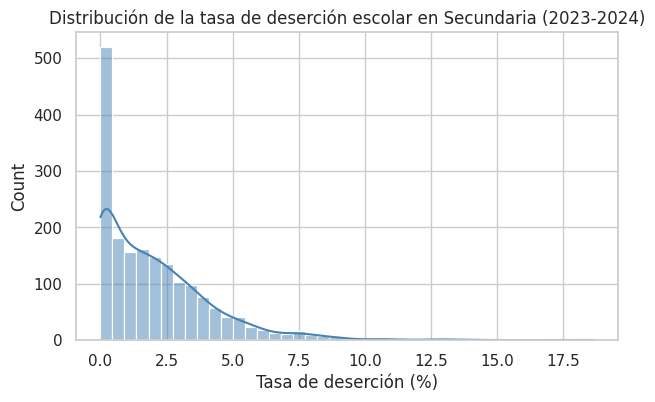

In [8]:
print(df_archivo["tasa_desercion_secundaria"].describe())
plt.figure(figsize=(7,4))
sns.histplot(df_archivo["tasa_desercion_secundaria"], kde=True, color="steelblue")
plt.title("Distribución de la tasa de deserción escolar en Secundaria (2023-2024)")
plt.xlabel("Tasa de deserción (%)")
plt.show()

Interpretacion de la variable TASA en el dataset de secundaria (2023-2024)
Se puede observar en el Histograma que la mayoria de distritos tienen tasas de desercion muy bajas , pero existen akgunos distritos que tienen las tasas mas altas pasando un poco mas del 7.5 porciento de desercion , asi que se define como riesgo alto a los valores que sean mayor o igual al 75 porciento se basara de ese umbral.
NOTA : Se puede utilizar otro percentil pero en este caso se utiliza el 75 porciento para obtener mas casos positivos para entrenar es como un punto intermedio de los valores que se puede entrenar.

# Generacion de la variable objetivo ---> Binaria

Se interpreta en este codigo que si la tasa de desercion es la regla que se aplicara para este proyecto

0 : Es de riego de desercion bajo

1 : Es de riesgo de desercion alto
- El umbral es de 75 porciento aquellos datos que superen ese umbral automaticamente se denominara como 1
- Aquellos datos que no superene automaticamente se denominara como 0

Asi definimos la generacion de variable objetivo Binaria

In [9]:
umbral = df_archivo["tasa_desercion_secundaria"].quantile(0.75)
df_archivo["riesgo_alto_desercion"] = (df_archivo["tasa_desercion_secundaria"] > umbral).astype(int)

print(f"Umbral (percentil 75): {umbral:.2f}%")
df_archivo[["Distrito", "tasa_desercion_secundaria", "riesgo_alto_desercion"]].head(8)

Umbral (percentil 75): 3.09%


,Distrito,tasa_desercion_secundaria,riesgo_alto_desercion
0,CHACHAPOYAS,1.227711,0
1,BALSAS,4.000000,1
2,CHETO,0.000000,0
3,CHUQUIBAMBA,4.093567,1
4,GRANADA,0.000000,0
5,LA JALCA,1.987768,0
6,LEIMEBAMBA,4.615385,1
7,LEVANTO,5.172414,1


# Visualización variable objetivo

/tmp/ipykernel_2009/4184048469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_archivo, x="riesgo_alto_desercion", palette="Set2")


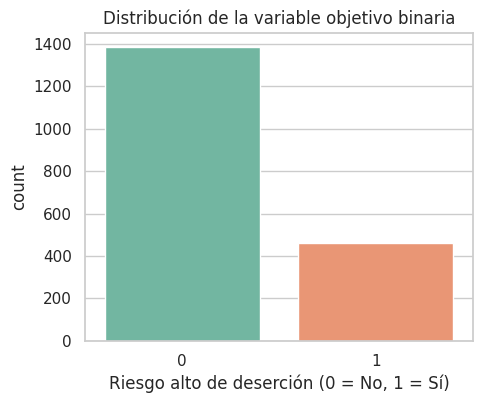

,proportion
riesgo_alto_desercion,
0,0.75
1,0.25


In [10]:
plt.figure(figsize=(5,4))
sns.countplot(data=df_archivo, x="riesgo_alto_desercion", palette="Set2")
plt.title("Distribución de la variable objetivo binaria")
plt.xlabel("Riesgo alto de deserción (0 = No, 1 = Sí)")
plt.show()

df_archivo["riesgo_alto_desercion"].value_counts(normalize=True).round(3)

## Interpretacion de variable objetivo Binaria
- Como se observa en el grafico existe una gran diferencia de la proporcion del riesgo de desercion hay muchas mas cantidades en el dataset de distritos sin riesgo de desercion a comparacion de distritos con riesgo de desercion , respectivamente es de 75 % y 25 % , al usar el 75 porciento como umbral , se observa que los datos estan muy desbalanceados.

# ANALISIS DE LAS VARIABLE PREDICTORAS

In [11]:
columnas_categoricas = ["Departamento"]
columnas_numericas = ["matriculados_secundaria", "tasa_desercion_primaria"]

print("Categoricas:", columnas_categoricas)
print("Numericas:", columnas_numericas)

Categoricas: ['Departamento']
Numericas: ['matriculados_secundaria', 'tasa_desercion_primaria']


Interpretacion : Se utilizan la variable Departamento como variable categorica debido a que engloba lo que daria provincia y Distrito estos mismo generarian muchas columnas y se tendria que sobreajustar el modelo completo.

# LA TASA DE DESERCION POR DEPARTAMENTO

/tmp/ipykernel_2009/2602126556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_archivo, x="Departamento", y="tasa_desercion_secundaria", order=orden, palette="viridis")


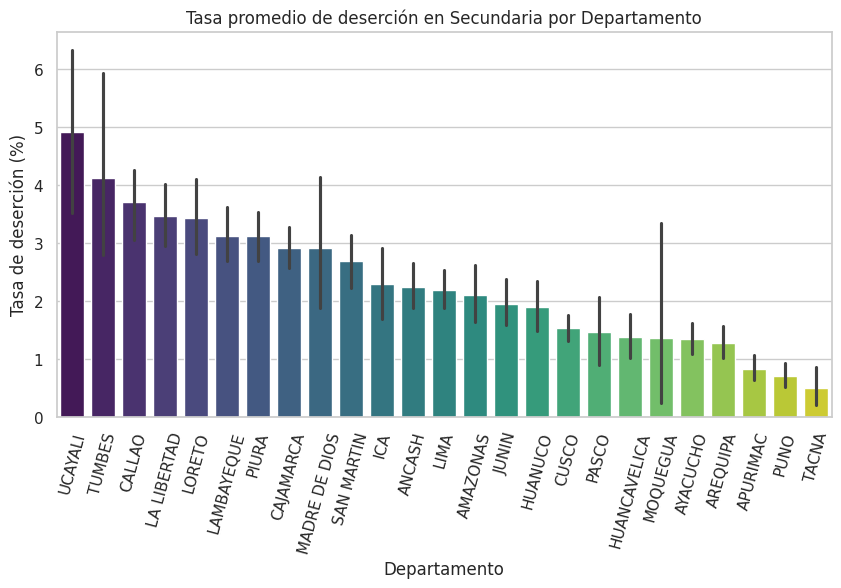

In [12]:
plt.figure(figsize=(10,5))
orden = df_archivo.groupby("Departamento")["tasa_desercion_secundaria"].mean().sort_values(ascending=False).index
sns.barplot(data=df_archivo, x="Departamento", y="tasa_desercion_secundaria", order=orden, palette="viridis")
plt.xticks(rotation=75)
plt.title("Tasa promedio de deserción en Secundaria por Departamento")
plt.ylabel("Tasa de deserción (%)")
plt.show()

### INTERPRETACION :
Se interpreta de este grafico , la tasa de desercion por cada departamento y se tiene la evidencia de manera cuantitativa de los departamentos que poseen mas probabilidades de desercion , esto justifica porque es interesante analizar y desglozar las partes analizadas para incluirlas como variable predictiva.

# LA RELACION DE DATASET PRIMARIA Y SECUNDARIA

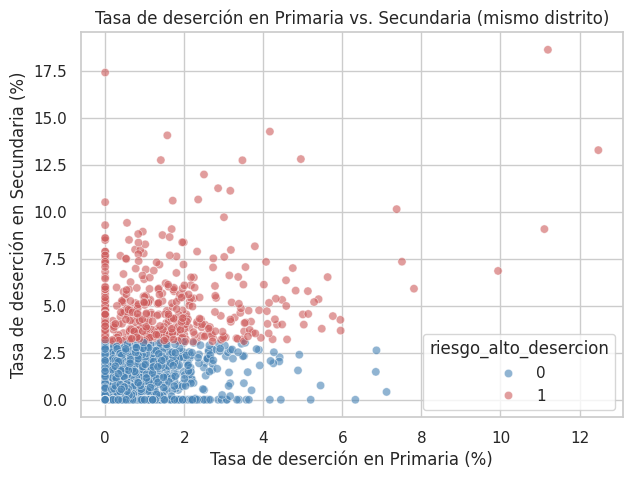

,tasa_desercion_primaria,tasa_desercion_secundaria
tasa_desercion_primaria,1.000000,0.396674
tasa_desercion_secundaria,0.396674,1.000000


In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_archivo, x="tasa_desercion_primaria", y="tasa_desercion_secundaria",
                 hue="riesgo_alto_desercion", alpha=0.6, palette={0:"steelblue", 1:"indianred"})
plt.title("Tasa de deserción en Primaria vs. Secundaria (mismo distrito)")
plt.xlabel("Tasa de deserción en Primaria (%)")
plt.ylabel("Tasa de deserción en Secundaria (%)")
plt.show()

df_archivo[["tasa_desercion_primaria", "tasa_desercion_secundaria"]].corr()

INTERPRETACION:

-Se interpreta de esta manera una comparacion de la tasa de desercion en los distritos tanto como en primaria y secundaria , existe una corelacion de forma positiva visuavisable en el grafico , con esto se justifica la razon que la tasa de desercion en el dataset primaria funciona como una variable predictora para el modelo de secundaria.

#  Matriculados en Secundaria vs La tasa de deserción en secundaria

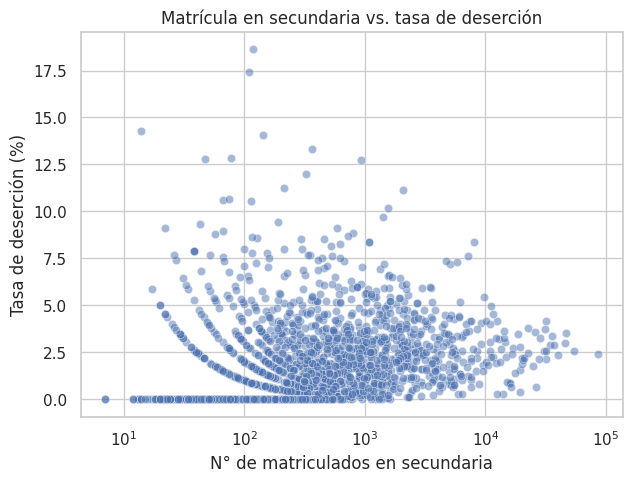

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_archivo, x="matriculados_secundaria", y="tasa_desercion_secundaria", alpha=0.5)
plt.xscale("log")
plt.title("Matrícula en secundaria vs. tasa de deserción")
plt.xlabel("N° de matriculados en secundaria")
plt.ylabel("Tasa de deserción (%)")
plt.show()

Interpretación:
Los distritos como (colegios chicos, generalmente los rurales) suelen mostrar mayor dispersión y las tasas más altas de deserción de estudiantes ; en cambio los distritos como las (zonas urbanas consolidadas) tienden a concentrarse en tasas más bajas y estables.

# Correlación entre variables numéricas

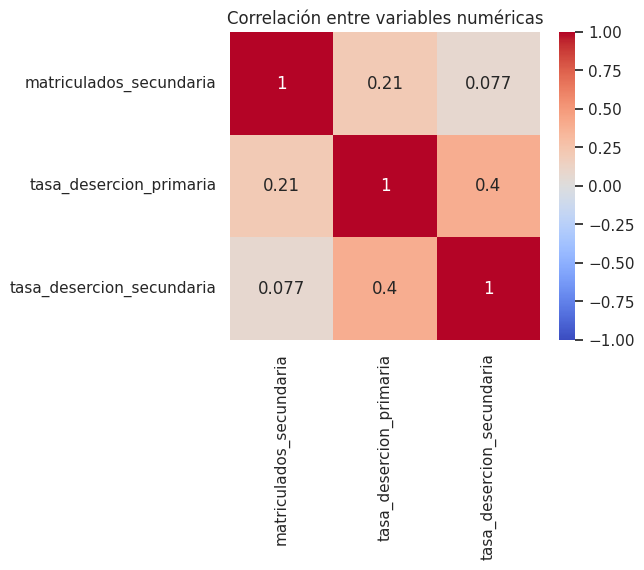

In [15]:
plt.figure(figsize=(5,4))
cols_corr = columnas_numericas + ["tasa_desercion_secundaria"]
sns.heatmap(df_archivo [cols_corr].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()

Interpretación:
- Se observa que correlacion positiva de desercion de la variable objetivo tasa desercion primaria y secundaria  es de 0.4 (Correlación moderada positiva)
- Tambien que la correlacion  en matriculados secundaria es de 0.077 con su tasa de desercion secundaria ( Correlación casi nula )

En resumen: En el gráfico se muestra que la deserción en primaria y secundaria están relacionadas, en cambio el numero de matriculados en secundaria con las duras penas influye en las tasas de abandono

# Se procede a Preparar los datos para el modelo

In [16]:
X = df_archivo[columnas_categoricas + columnas_numericas].copy()
y = df_archivo["riesgo_alto_desercion"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
print("Proporción riesgo alto (train):", y_train.mean().round(3))
print("Proporción riesgo alto (test):", y_test.mean().round(3))

Entrenamiento: (1384, 3)  Prueba: (462, 3)
Proporción riesgo alto (train): 0.25
Proporción riesgo alto (test): 0.251


Interpretacion :
La división de datos
stratify=y asegura que la proporción ~25% de distritos en riesgo alto se mantenga similar en entrenamiento y prueba. El escalador y el K-Means se ajustan solo con X_train para evitar data leakage hacia el conjunto de prueba.

# Pipeline de preprocesamiento

In [17]:
transformador_categorico = OneHotEncoder(handle_unknown="ignore")
transformador_numerico = StandardScaler()

preprocesador = ColumnTransformer([
    ("cat", transformador_categorico, columnas_categoricas),
    ("num", transformador_numerico, columnas_numericas),
])
print("Preprocesador construido.")


Preprocesador construido.


Interpretación:
Departamento se codifica con One-Hot (25 columnas binarias); las dos variables numéricas se estandarizan, requisito indispensable para que K-Means calcule distancias de forma correcta y que además ayuda a la convergencia de la Regresión Logística.

# Agrupamiento con K-Means (modelo no supervisado)
K-Means agrupa distritos según su matrícula y su tasa de deserción en primaria, sin conocer el riesgo real en secundaria. Buscamos perfiles distritales que luego aporten información a la Regresión Logística.

In [18]:
scaler_kmeans = StandardScaler()
X_train_num_scaled = scaler_kmeans.fit_transform(X_train[columnas_numericas])
X_test_num_scaled = scaler_kmeans.transform(X_test[columnas_numericas])

print("Variables usadas para K-Means:", columnas_numericas)
X_train_num_scaled[:3]

Variables usadas para K-Means: ['matriculados_secundaria', 'tasa_desercion_primaria']


array([[-0.231224  , -0.41045242],
       [-0.30426108, -0.78237024],
       [-0.278134  , -0.56863519]])

## Selección de k: método del codo y silhouette


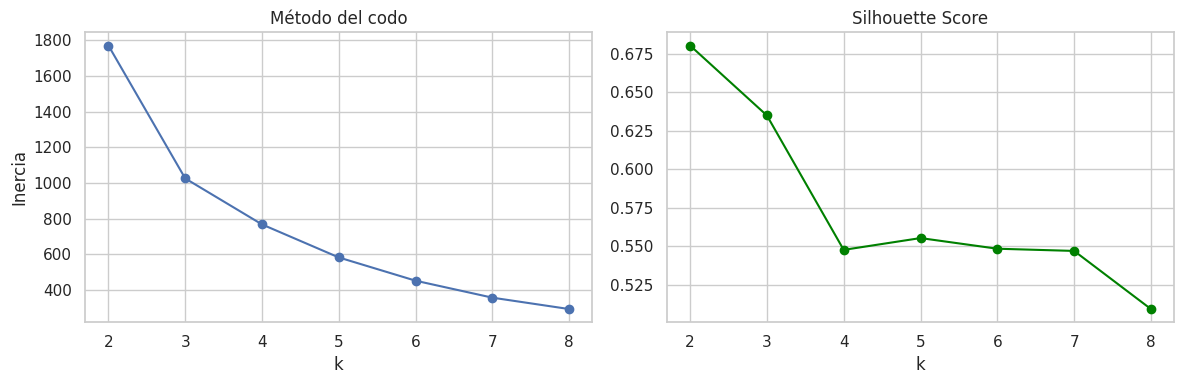

k=2  silhouette=0.680  davies-bouldin=1.018
k=3  silhouette=0.635  davies-bouldin=0.688
k=4  silhouette=0.548  davies-bouldin=0.729
k=5  silhouette=0.555  davies-bouldin=0.658
k=6  silhouette=0.549  davies-bouldin=0.626
k=7  silhouette=0.547  davies-bouldin=0.555
k=8  silhouette=0.509  davies-bouldin=0.619


In [19]:
inercias, siluetas, db_scores = [], [], []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = km.fit_predict(X_train_num_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_train_num_scaled, etiquetas))
    db_scores.append(davies_bouldin_score(X_train_num_scaled, etiquetas))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(rango_k), inercias, marker="o")
axes[0].set_title("Método del codo"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(list(rango_k), siluetas, marker="o", color="green")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

for k, s, d in zip(rango_k, siluetas, db_scores):
    print(f"k={k}  silhouette={s:.3f}  davies-bouldin={d:.3f}")

Interpretacion:
El metodo del “codo” se observa alrededor de k = 3 o 4, lo que sugiere que ahí está el punto donde añadir más clusters ya no mejora mucho la compactación.
El metodo del Silhouete Score a medida que aumentan los clusters, el score baja, indicando menor calidad de separación

In [20]:
K_OPTIMO = int(pd.Series(siluetas, index=list(rango_k)).idxmax())
print("k elegido automáticamente por silhouette máximo:", K_OPTIMO)
print("(Ajusta K_OPTIMO)")

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10)
cluster_train = kmeans.fit_predict(X_train_num_scaled)
cluster_test = kmeans.predict(X_test_num_scaled)

X_train = X_train.copy(); X_train["cluster"] = cluster_train.astype(str)
X_test = X_test.copy(); X_test["cluster"] = cluster_test.astype(str)

pd.Series(cluster_train).value_counts().sort_index()

k elegido automáticamente por silhouette máximo: 2
(Ajusta K_OPTIMO)


,count
0,1198
1,186


# Visualización de los clústeres

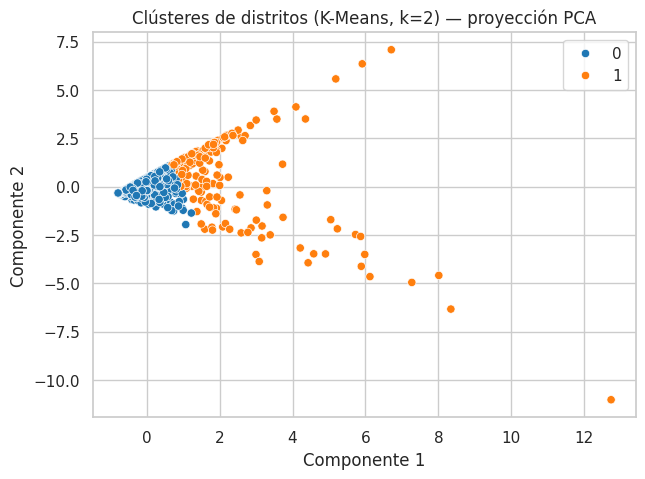

In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_train_num_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=cluster_train, palette="tab10")
plt.title(f"Clústeres de distritos (K-Means, k={K_OPTIMO}) — proyección PCA")
plt.xlabel("Componente 1"); plt.ylabel("Componente 2")
plt.show()

INTERPRETACION:
Se utilizo  2 CLUSTERES
El clustering sugiere que los distritos pueden dividirse en dos perfiles principales:

- Distritos con características más homogéneas y bajas tasas.

- Distritos con mayor dispersión en matrícula y deserción, reflejando más heterogeneidad.

# Se visualiza el perfil de cada clúster

In [22]:
PERFIL_CLUSTER = X_train.copy()
PERFIL_CLUSTER["riesgo_alto_desercion"] = y_train.values
PERFIL_CLUSTER.groupby("cluster")[columnas_numericas + ["riesgo_alto_desercion"]].mean().round(2)

,matriculados_secundaria,tasa_desercion_primaria,riesgo_alto_desercion
cluster,,,
0,794.90,0.59,0.21
1,7441.79,3.09,0.48


Interpretacion:
Se observa que si algún clúster concentra distritos de matrícula pequeña y alta deserción en primaria, y si ese mismo clúster tiene una proporción notablemente mayor de riesgo alto de desercion. Si sucede asi entonces el agrupamiento capturó un patrón real y util para la fase predictiva.

# Predicción con Regresión Logística (modelo supervisado)
Comparamos dos experimentos:

E2: Regresión Logística con Departamento, matriculados_secundaria y tasa_desercion_primaria (sin clúster).

E3: las mismas variables más el cluster hallado por K-Means.

In [23]:
def construir_pipeline(usar_cluster: bool):
    cat_cols = columnas_categoricas + (["cluster"] if usar_cluster else [])
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), columnas_numericas),
    ])
    modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    return Pipeline([("prep", prep), ("clf", modelo)])

print("Función de construcción de pipeline lista.")

Función de construcción de pipeline lista.


# Experimento E2: Regresión Logística sin clúster

In [24]:
grid_E2 = GridSearchCV(construir_pipeline(usar_cluster=False),
                        param_grid={"clf__C": [0.01, 0.1, 1, 10]}, scoring="f1", cv=5)
grid_E2.fit(X_train, y_train)
modelo_E2 = grid_E2.best_estimator_
print("Mejor C (E2):", grid_E2.best_params_)

y_pred_E2 = modelo_E2.predict(X_test)
y_proba_E2 = modelo_E2.predict_proba(X_test)[:, 1]

metricas_E2 = {
    "experimento": "E2 (sin cluster)",
    "accuracy": accuracy_score(y_test, y_pred_E2),
    "precision": precision_score(y_test, y_pred_E2),
    "recall": recall_score(y_test, y_pred_E2),
    "f1": f1_score(y_test, y_pred_E2),
    "auc": roc_auc_score(y_test, y_proba_E2),
}
print(classification_report(y_test, y_pred_E2, digits=3))
metricas_E2

Mejor C (E2): {'clf__C': 10}
              precision    recall  f1-score   support

           0      0.786     0.945     0.858       346
           1      0.587     0.233     0.333       116

    accuracy                          0.766       462
   macro avg      0.687     0.589     0.596       462
weighted avg      0.736     0.766     0.726       462



{'experimento': 'E2 (sin cluster)',
 'accuracy': 0.7662337662337663,
 'precision': 0.5869565217391305,
 'recall': 0.23275862068965517,
 'f1': 0.3333333333333333,
 'auc': np.float64(0.7318492126768986)}

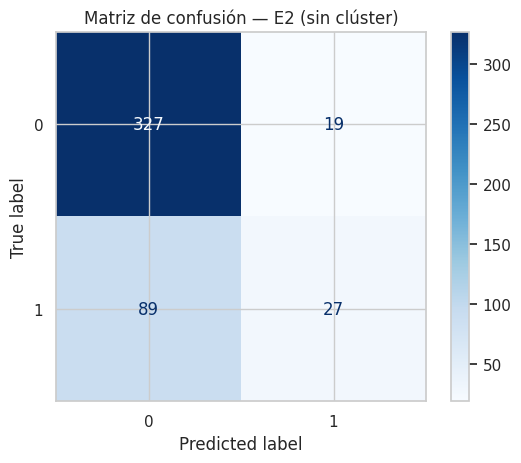

In [25]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_E2)).plot(cmap="Blues")
plt.title("Matriz de confusión — E2 (sin clúster)")
plt.show()

Interpretación de la imagen
Se observa especialmente los falsos negativos (distritos con riesgo alto real que el modelo clasificó como bajo): son el error más costoso en un problema de política educativa, porque implican no intervenir a tiempo donde sí se necesitaba.

# Experimento E3: Regresión Logística con clúster de K-Means

In [26]:
grid_E3 = GridSearchCV(construir_pipeline(usar_cluster=True),
                        param_grid={"clf__C": [0.01, 0.1, 1, 10]}, scoring="f1", cv=5)
grid_E3.fit(X_train, y_train)
modelo_E3 = grid_E3.best_estimator_
print("Mejor C (E3):", grid_E3.best_params_)

y_pred_E3 = modelo_E3.predict(X_test)
y_proba_E3 = modelo_E3.predict_proba(X_test)[:, 1]

metricas_E3 = {
    "experimento": "E3 (con cluster)",
    "accuracy": accuracy_score(y_test, y_pred_E3),
    "precision": precision_score(y_test, y_pred_E3),
    "recall": recall_score(y_test, y_pred_E3),
    "f1": f1_score(y_test, y_pred_E3),
    "auc": roc_auc_score(y_test, y_proba_E3),
}
print(classification_report(y_test, y_pred_E3, digits=3))
metricas_E3


Mejor C (E3): {'clf__C': 10}
              precision    recall  f1-score   support

           0      0.785     0.948     0.859       346
           1      0.591     0.224     0.325       116

    accuracy                          0.766       462
   macro avg      0.688     0.586     0.592       462
weighted avg      0.736     0.766     0.725       462



{'experimento': 'E3 (con cluster)',
 'accuracy': 0.7662337662337663,
 'precision': 0.5909090909090909,
 'recall': 0.22413793103448276,
 'f1': 0.325,
 'auc': np.float64(0.7321481961331473)}

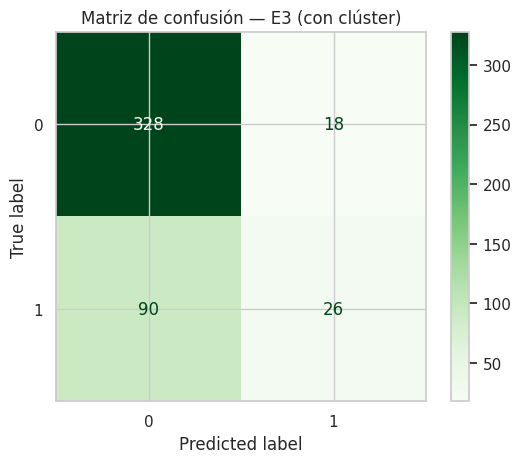

In [27]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_E3)).plot(cmap="Greens")
plt.title("Matriz de confusión — E3 (con clúster)")
plt.show()

Interpretación:
Esta imagen se compara con la matriz de E2, en especial los falsos negativos. Si se reducen, el clúster está ayudando al modelo a detectar mejor a los distritos en riesgo real.

# Comparación de experimentos (E2 vs. E3)

In [28]:
comparacion = pd.DataFrame([metricas_E2, metricas_E3]).set_index("experimento")
comparacion.round(3)

,accuracy,precision,recall,f1,auc
experimento,,,,,
E2 (sin cluster),0.766,0.587,0.233,0.333,0.732
E3 (con cluster),0.766,0.591,0.224,0.325,0.732


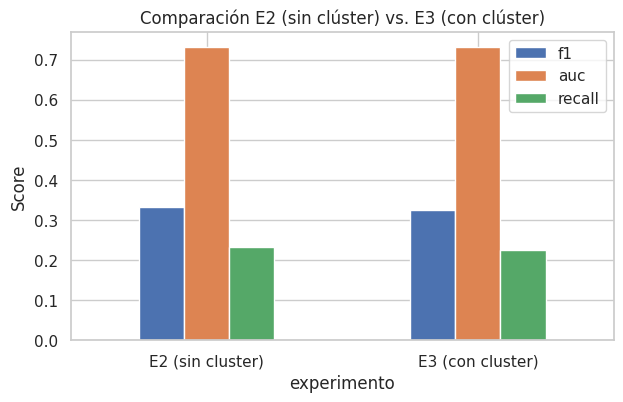

In [29]:
comparacion[["f1", "auc", "recall"]].plot(kind="bar", figsize=(7,4))
plt.title("Comparación E2 (sin clúster) vs. E3 (con clúster)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Interpretación de la comparación de experimentos :   
Esta es la evidencia central del proyecto: si F1 y AUC mejoran en E3 respecto a E2, se demuestra cuantitativamente que el modelo no supervisado (K-Means) aportó información real al modelo supervisado (Regresión Logística).

## **Validación cruzada**

In [30]:
cv_E2 = cross_val_score(modelo_E2, X_train, y_train, cv=5, scoring="f1")
cv_E3 = cross_val_score(modelo_E3, X_train, y_train, cv=5, scoring="f1")

print("F1 por fold — E2:", cv_E2.round(3), " | media:", cv_E2.mean().round(3))
print("F1 por fold — E3:", cv_E3.round(3), " | media:", cv_E3.mean().round(3))

F1 por fold — E2: [0.247 0.355 0.34  0.25  0.301]  | media: 0.299
F1 por fold — E3: [0.261 0.355 0.34  0.25  0.277]  | media: 0.297


## **Curva ROC y AUC**

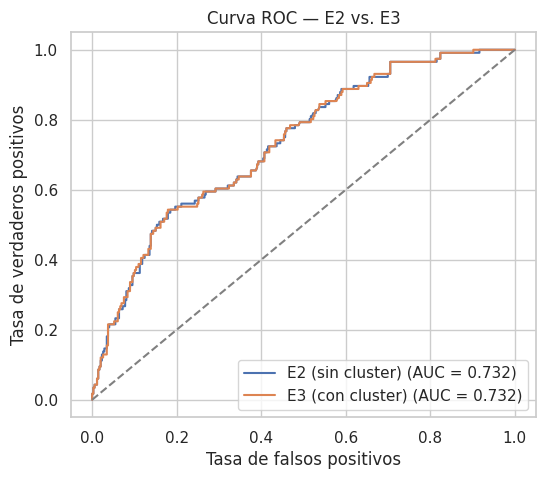

In [31]:
plt.figure(figsize=(6,5))
for nombre, y_proba in [("E2 (sin cluster)", y_proba_E2), ("E3 (con cluster)", y_proba_E3)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — E2 vs. E3")
plt.legend()
plt.show()

Interpretación de la curva ROC y del AUC
La curva más alejada de la diagonal discrimina mejor entre distritos con y sin riesgo alto, en todos los posibles puntos de corte, no solo en 0.5.

Interpretabilidad de las variables con mayor influencia

Modelo ganador: E2 (sin cluster)


/tmp/ipykernel_2009/3040536265.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=odds_ratios.head(15), x="coeficiente", y="variable", palette="coolwarm")


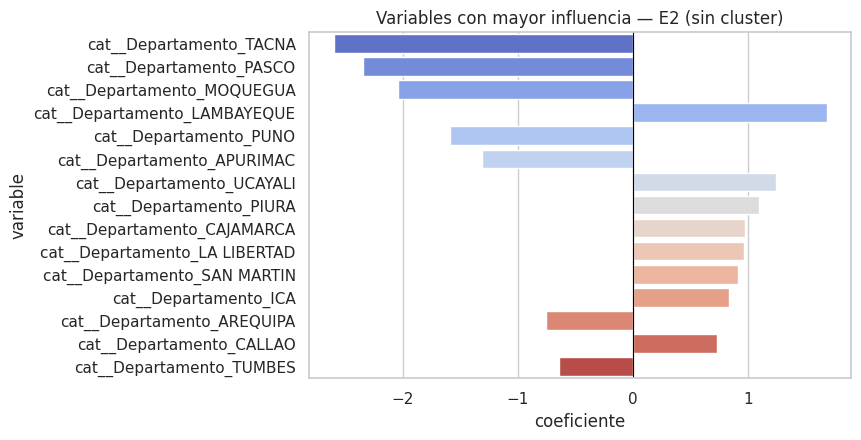

,variable,coeficiente,odds_ratio
22,cat__Departamento_TACNA,-2.600148,0.074263
18,cat__Departamento_PASCO,-2.346647,0.095689
17,cat__Departamento_MOQUEGUA,-2.040392,0.129978
13,cat__Departamento_LAMBAYEQUE,1.680181,5.366529
20,cat__Departamento_PUNO,-1.589141,0.204101
2,cat__Departamento_APURIMAC,-1.311204,0.269495
24,cat__Departamento_UCAYALI,1.241969,3.462424
19,cat__Departamento_PIURA,1.090744,2.976488
5,cat__Departamento_CAJAMARCA,0.969707,2.637171
12,cat__Departamento_LA LIBERTAD,0.965573,2.626291


In [32]:
modelo_ganador = modelo_E3 if metricas_E3["f1"] >= metricas_E2["f1"] else modelo_E2
nombre_ganador = metricas_E3["experimento"] if metricas_E3["f1"] >= metricas_E2["f1"] else metricas_E2["experimento"]
print("Modelo ganador:", nombre_ganador)

nombres_features = modelo_ganador.named_steps["prep"].get_feature_names_out()
coeficientes = modelo_ganador.named_steps["clf"].coef_[0]

odds_ratios = pd.DataFrame({
    "variable": nombres_features,
    "coeficiente": coeficientes,
    "odds_ratio": np.exp(coeficientes),
}).sort_values("coeficiente", key=abs, ascending=False)

plt.figure(figsize=(7, max(4, len(odds_ratios.head(15)) * 0.3)))
sns.barplot(data=odds_ratios.head(15), x="coeficiente", y="variable", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Variables con mayor influencia — {nombre_ganador}")
plt.show()

odds_ratios.head(15)

Interpretación de los coeficientes
Un odds_ratio > 1 aumenta la probabilidad de riesgo alto frente a la categoría/variable base; odds_ratio < 1 la reduce. Relaciona los departamentos y variables que aparecen arriba con lo que ya observaste en el EDA (sección de tasa de deserción por Departamento) — deberían coincidir.

# Selección justificada del modelo final
Se observa que en la comparacion de los dos modelos tanto en el Logistico y el complemento de clusteres de K-Means una pequeña mejor en F1 y Recall , lo mejor seria utilizar otro tipo de modelo como por ejemplo RAMDOM FOREST debido que lo mas probable daria resultados mucho mejores.Debido que no se ve una gran diferencia de mejoria en ese modelo predictivo.

***Pero para este proyecto basta con la progresion Logistica sin cluster debido que no hay mucha diferencia.***
               
                accuracy	precision	recall	  f1	    auc
E2 (sin cluster)	0.766	    0.587   0.233    0.333	   0.732


E3 (con cluster)	0.766	    0.591	   0.224	  0.325	  0.732

# Amenazas a la validez y limitaciones
- Validez interna: el umbral de riesgo alto (percentil 75) es una decisión de diseño; prueba su sensibilidad con otros umbrales (por ejemplo, la mediana).
- Validez externa: los resultados corresponden a 2023-2024 y no necesariamente se generalizan a otros años sin reentrenar.
- Validez de constructo: la tasa de deserción interanual del SIAGIE es una aproximación al fenómeno real de abandono escolar, no una medida perfecta.
- Limitación de variables: solo se cuenta con variables geográficas y de matrícula; no hay información socioeconómica, de infraestructura educativa o de área urbana/rural en estos archivos — una futura versión del proyecto podría enriquecer el dataset combinando con el Censo Escolar (ESCALE) del MINEDU.

# Consideraciones éticas
Los datos utilizados del dataset son agregados a nivel distrital, publicados oficialmente por el MINEDU, y no contienen información identificable de estudiantes individuales. Aun así, cualquier uso de este modelo para orientar decisiones de política educativa (por ejemplo, asignación de recursos) debería pasar por validación adicional con especialistas del sector y un análisis explícito de posibles sesgos territoriales.

# Conclusiones finales
En este proyecto se combino dos fuentes reales y oficiales del MINEDU (tasas de deserción en Primaria y Secundaria 2023-2024) para construir una solución de dos fases:

K-Means agrupó a los distritos según su matrícula y su historial de deserción en primaria, sin conocer la etiqueta real de riesgo en secundaria.
Regresión Logística predijo el riesgo de deserción en secundaria, comparando un modelo sin el clúster (E2) contra uno que lo incorpora (E3).

	accuracy	precision	recall	f1	auc


E2 (sin cluster)	0.766	0.587	0.233	0.333	0.732

E3 (con cluster)	0.766	0.591	0.224	0.325	0.732

Este proyecto podria mejor en el tema de las variables , se podria tener mas datos que ayuden en la toma de decision para mejorar el modelo predictivo en su precision pero estoy conforme con lo avanzado en lo aplicado en clase.

# Anexo final y referencias
## Datasets utilizados
Tasa y número de desertores en Educación Primaria 2023-2024 — MINEDU, Plataforma Nacional de Datos Abiertos del Perú.
Tasa y número de desertores en Educación Secundaria 2023-2024 — MINEDU, Plataforma Nacional de Datos Abiertos del Perú.

Fuente: https://www.datosabiertos.gob.pe/dataset/tasa-y-n%C3%BAmero-de-desertores-en-educaci%C3%B3n-primaria-y-secundaria-20232024

## Variable objetivo
**tasa**: binaria, construida a partir del percentil 75 de la tasa de deserción en Educación Secundaria 2023-2024, a nivel distrital.
La variable es **TASA** es numerica (se calculara la tasa de desercion escolar)

1 : riesgo alto de desercion

0 : riesgo bajo de desercion

## Variables predictoras reales utilizadas
Departamento (categórica, 25 valores)
matriculados_secundaria (numérica, denominador del archivo de secundaria)
tasa_desercion_primaria (numérica, Tasa del archivo de primaria, mismo distrito)
Arquitectura de modelos
K-Means (no supervisado, agrupa) → Regresión Logística (supervisado, predice usando opcionalmente el clúster). Los dos modelos se complementan
##Referencias de proyecto
Este proyecto fue a base de inspiracion a un proyecto similar que es el de aqui
https://github.com/canevadop-dev/proyecto-datamining/blob/main/README.md
Es similar con otro tipo de enfoque y modelo utilizado "canevadop-dev" es el usuario que publico el proyecto.

Autoría y atribución
Este cuaderno forma parte del material educativo desarrollado por NICOLASTORRES.

📧 Contacto: nicolastorresyucra@gmail.com

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.